# Employee Salary Analysis & Compensation Modeling
### Internship Project Report | Software Solutions and Services Patna
**Author:** Rahul (Data Analysis Intern)  
**Domain:** Data Analytics & Machine Learning using Python  
**Tools & Libraries:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn

---

## 1. Executive Summary & Project Objectives

In modern organization management, compensation analytics plays a pivotal role in maintaining internal equity, attracting top talent, and optimizing budget allocation. This project performs an end-to-end data analysis of employee salary distributions across various dimensions including experience, education, department, job role, performance rating, and geographical location (comparing regional centers like Patna against major tech hubs such as Bangalore and Mumbai).

### Key Project Objectives:
1. **Data Ingestion & Hygiene**: Load raw employee dataset and perform comprehensive data cleaning (imputing missing values, removing duplicate records, standardizing categorical text, and filtering statistical outliers via IQR).
2. **Exploratory Data Analysis (EDA)**: Uncover trends, distributions, and correlations using rich graphical representations (histograms, boxplots, scatter trendlines, and heatmaps).
3. **Diversity & Equity Assessment**: Evaluate gender representation and pay parity across departments.
4. **Performance & Bonus Alignment**: Analyze the relationship between performance ratings and bonus payouts.
5. **Predictive Salary Modeling**: Train and evaluate Machine Learning regression models (**Linear Regression** and **Random Forest Regressor**) to predict base salary based on employee attributes.

---
## 2. Environment Setup & Data Loading

We begin by setting up the Python environment, configuring visualization styles, and reading the dataset `employee_salary_data.csv`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 100

# Load dataset
df_raw = pd.read_csv("employee_salary_data.csv")

print("Dataset Loaded Successfully!")
print(f"Total Rows: {df_raw.shape[0]}, Total Columns: {df_raw.shape[1]}")
display(df_raw.head(10))

Dataset Loaded Successfully!
Total Rows: 1208, Total Columns: 12


,Employee_ID,Name,Gender,Age,Department,Job_Title,Years_of_Experience,Education_Level,Location,Performance_Rating,Base_Salary_INR,Bonus_INR
0,EMP1001,Rahul Pandey,Male,30,Human Resources,HR Associate,7,Bachelor's,Delhi NCR,2,1137000.0,34100.0
1,EMP1002,Abhishek Mishra,Male,31,Engineering,Software Engineer,8,Bachelor's,Bangalore,3,1480000.0,118400.0
2,EMP1003,Aditya Verma,Male,31,Product Management,Senior Product Manager,5,PhD,Pune,3,2265000.0,181200.0
3,EMP1004,Preeti Roy,Female,37,Engineering,Senior Developer,12,PhD,Hyderabad,3,3958000.0,316600.0
4,EMP1005,Rajesh Gupta,Male,26,Engineering,Software Engineer,4,NaN,Hyderabad,4,1091000.0,152700.0
5,EMP1006,Preeti Kumar,Female,26,Product Management,Product Manager,4,PhD,Pune,2,2019000.0,60600.0
6,EMP1007,Sonam Yadav,Female,29,Finance,Accountant,6,PhD,Delhi NCR,2,1474000.0,44200.0
7,EMP1008,Rajesh Jha,Male,25,Engineering,Senior Developer,0,Bachelor's,Hyderabad,3,708000.0,56600.0
8,EMP1009,Ananya Gupta,Female,25,Human Resources,HR Associate,1,PhD,Delhi NCR,5,852000.0,187400.0
9,EMP1010,Abhishek Yadav,Male,27,Data Science,Data Scientist,2,Bachelor's,Pune,3,585000.0,46800.0


### Initial Data Inspection
Let's inspect data types, missing value counts, and baseline statistics.

In [2]:
# Data Structure & Types
print("--- Data Info ---")
df_raw.info()

print("\n--- Summary Statistics (Numeric) ---")
display(df_raw.describe().round(2))

print("\n--- Missing Values Count ---")
print(df_raw.isnull().sum())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          1208 non-null   str    
 1   Name                 1208 non-null   str    
 2   Gender               1208 non-null   str    
 3   Age                  1208 non-null   int64  
 4   Department           1208 non-null   str    
 5   Job_Title            1208 non-null   str    
 6   Years_of_Experience  1208 non-null   int64  
 7   Education_Level      1198 non-null   str    
 8   Location             1208 non-null   str    
 9   Performance_Rating   1208 non-null   int64  
 10  Base_Salary_INR      1193 non-null   float64
 11  Bonus_INR            1208 non-null   float64
dtypes: float64(2), int64(3), str(7)
memory usage: 191.9 KB

--- Summary Statistics (Numeric) ---


,Age,Years_of_Experience,Performance_Rating,Base_Salary_INR,Bonus_INR
count,1208.00,1208.00,1208.00,1193.00,1208.00
mean,30.27,5.69,3.16,1795421.63,165618.54
std,4.04,3.61,0.96,1850147.15,136076.69
min,22.00,0.00,1.00,-500000.00,0.00
25%,27.00,3.00,3.00,1101000.00,71075.00
50%,30.00,6.00,3.00,1559000.00,129800.00
75%,33.00,8.00,4.00,2193000.00,220625.00
max,43.00,18.00,5.00,45000000.00,1074700.00



--- Missing Values Count ---
Employee_ID             0
Name                    0
Gender                  0
Age                     0
Department              0
Job_Title               0
Years_of_Experience     0
Education_Level        10
Location                0
Performance_Rating      0
Base_Salary_INR        15
Bonus_INR               0
dtype: int64


---
## 3. Data Cleaning & Preprocessing

Real-world datasets often contain noise, missing values, formatting inconsistencies, and data entry errors. To ensure robust analysis and unbiased machine learning models, we execute a structured data cleaning pipeline:

1. **Duplicate Elimination**: Detect and drop duplicate employee records.
2. **Text Standardization**: Trim leading/trailing whitespace and standardize text casing in `Location` and `Department`.
3. **Missing Value Imputation**: Fill nulls using mode for categorical features and median grouped by `Job_Title` for numeric salary entries.
4. **Outlier Filtering**: Use the Interquartile Range (IQR) method to filter out erroneous salary inputs (e.g., negative values or severe data entry typos).

In [3]:
# Step 1: Remove Duplicates
initial_count = len(df_raw)
df_clean = df_raw.drop_duplicates().copy()
removed_dups = initial_count - len(df_clean)
print(f"Removed {removed_dups} duplicate records. Remaining records: {len(df_clean)}")

# Step 2: Text Standardization
df_clean['Location'] = df_clean['Location'].astype(str).str.strip().str.title()
df_clean['Department'] = df_clean['Department'].astype(str).str.strip().str.title()

# Fix any casing inconsistencies from text formatting
df_clean['Location'] = df_clean['Location'].replace({'Delhi Ncr': 'Delhi NCR'})

# Step 3: Handle Missing Values
print("\nMissing values before imputation:")
print(df_clean[['Education_Level', 'Base_Salary_INR']].isnull().sum())

# Impute Education_Level with Mode
mode_edu = df_clean['Education_Level'].mode()[0]
df_clean['Education_Level'] = df_clean['Education_Level'].fillna(mode_edu)

# Impute Base_Salary_INR with median based on Experience & Education group
df_clean['Base_Salary_INR'] = df_clean.groupby(['Years_of_Experience', 'Education_Level'])['Base_Salary_INR'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback for remaining NaNs
df_clean['Base_Salary_INR'] = df_clean['Base_Salary_INR'].fillna(df_clean['Base_Salary_INR'].median())

print("\nMissing values after imputation:")
print(df_clean.isnull().sum())

Removed 8 duplicate records. Remaining records: 1200

Missing values before imputation:
Education_Level    10
Base_Salary_INR    15
dtype: int64

Missing values after imputation:
Employee_ID            0
Name                   0
Gender                 0
Age                    0
Department             0
Job_Title              0
Years_of_Experience    0
Education_Level        0
Location               0
Performance_Rating     0
Base_Salary_INR        0
Bonus_INR              0
dtype: int64


### Outlier Identification & Removal using IQR
We identify extreme outliers in `Base_Salary_INR` using the Interquartile Range (IQR) thresholding rule:
$$Q_1 = 25\text{th percentile}, \quad Q_3 = 75\text{th percentile}, \quad \text{IQR} = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$

In [4]:
# Calculate IQR for Base Salary
Q1 = df_clean['Base_Salary_INR'].quantile(0.25)
Q3 = df_clean['Base_Salary_INR'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Salary Q1: ₹{Q1:,.2f}")
print(f"Salary Q3: ₹{Q3:,.2f}")
print(f"IQR: ₹{IQR:,.2f}")
print(f"Valid Salary Range (IQR): ₹{lower_bound:,.2f} to ₹{upper_bound:,.2f}")

# Identify outliers
outliers = df_clean[(df_clean['Base_Salary_INR'] < lower_bound) | (df_clean['Base_Salary_INR'] > upper_bound)]
print(f"Identified {len(outliers)} severe salary outliers.")
display(outliers[['Employee_ID', 'Name', 'Job_Title', 'Base_Salary_INR']])

# Filter out outliers and negative values
df_clean = df_clean[(df_clean['Base_Salary_INR'] >= 300000) & (df_clean['Base_Salary_INR'] <= upper_bound)].copy()
df_clean.reset_index(drop=True, inplace=True)
print(f"\nFinal Cleaned Dataset Size: {len(df_clean)} records.")

Salary Q1: ₹1,099,750.00
Salary Q3: ₹2,194,250.00
IQR: ₹1,094,500.00
Valid Salary Range (IQR): ₹-542,000.00 to ₹3,836,000.00
Identified 34 severe salary outliers.


,Employee_ID,Name,Job_Title,Base_Salary_INR
3,EMP1004,Preeti Roy,Senior Developer,3958000.0
72,EMP1073,Shweta Das,Marketing Director,4158000.0
110,EMP1111,Amit Verma,Senior Product Manager,4530000.0
117,EMP1118,Alok Jha,Marketing Director,4420000.0
142,EMP1143,Rajesh Sinha,HR Manager,4863000.0
187,EMP1188,Divya Das,Finance Manager,4096000.0
238,EMP1239,Amit Jha,Marketing Director,4487000.0
239,EMP1240,Priya Gupta,Associate Product Manager,4495000.0
244,EMP1245,Priya Yadav,Finance Manager,4474000.0
276,EMP1277,Kavita Pandey,Sales Executive,38000000.0



Final Cleaned Dataset Size: 1164 records.


---
## 4. Exploratory Data Analysis (EDA) & Visualizations

Now we analyze clean data to extract meaningful business insights and patterns.

### 4.1 Base Salary Distribution Analysis
We inspect the frequency distribution and kernel density estimate (KDE) of employee base salaries.

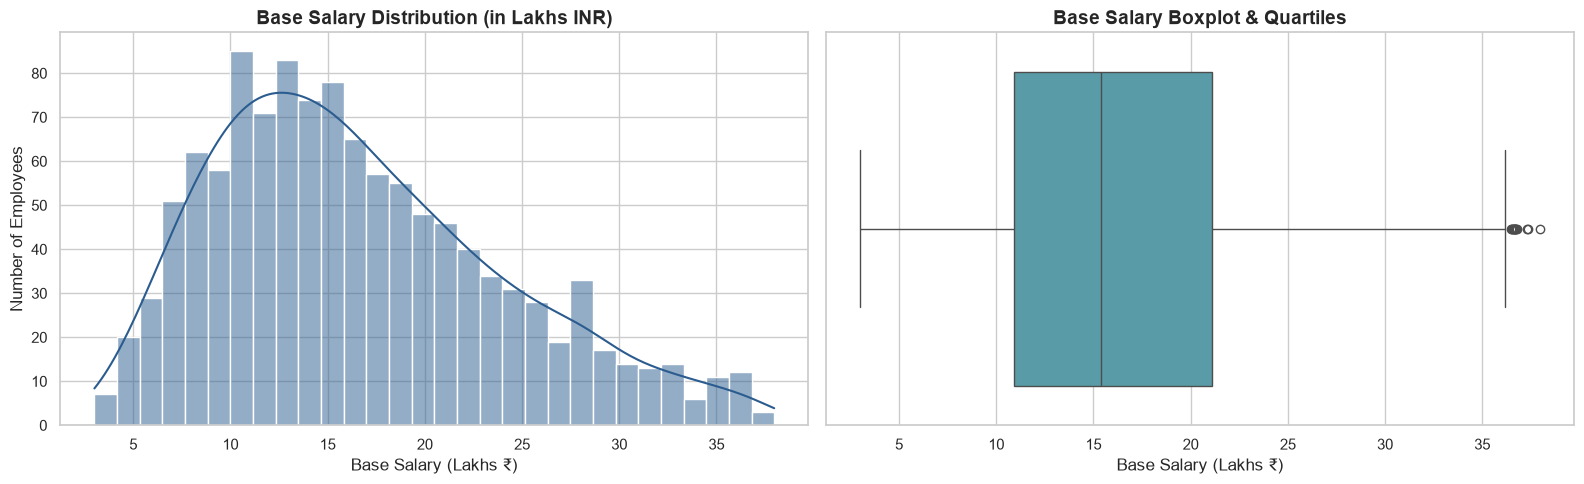

Mean Salary: ₹1,658,710.48
Median Salary: ₹1,536,500.00
Salary Skewness Coefficient: 0.648 (Right-skewed distribution)


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histogram & KDE
sns.histplot(df_clean['Base_Salary_INR'] / 100000, kde=True, color='#2b5c8f', bins=30, ax=ax[0])
ax[0].set_title("Base Salary Distribution (in Lakhs INR)", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Base Salary (Lakhs ₹)", fontsize=12)
ax[0].set_ylabel("Number of Employees", fontsize=12)

# Plot 2: Boxplot for Skewness
sns.boxplot(x=df_clean['Base_Salary_INR'] / 100000, color='#4ca5b5', ax=ax[1])
ax[1].set_title("Base Salary Boxplot & Quartiles", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Base Salary (Lakhs ₹)", fontsize=12)

plt.tight_layout()
plt.show()

# Print Skewness
skew = df_clean['Base_Salary_INR'].skew()
mean_sal = df_clean['Base_Salary_INR'].mean()
median_sal = df_clean['Base_Salary_INR'].median()

print(f"Mean Salary: ₹{mean_sal:,.2f}")
print(f"Median Salary: ₹{median_sal:,.2f}")
print(f"Salary Skewness Coefficient: {skew:.3f} (Right-skewed distribution)")

### 4.2 Salary Analysis Across Departments
Let's analyze how compensation varies across functional departments.

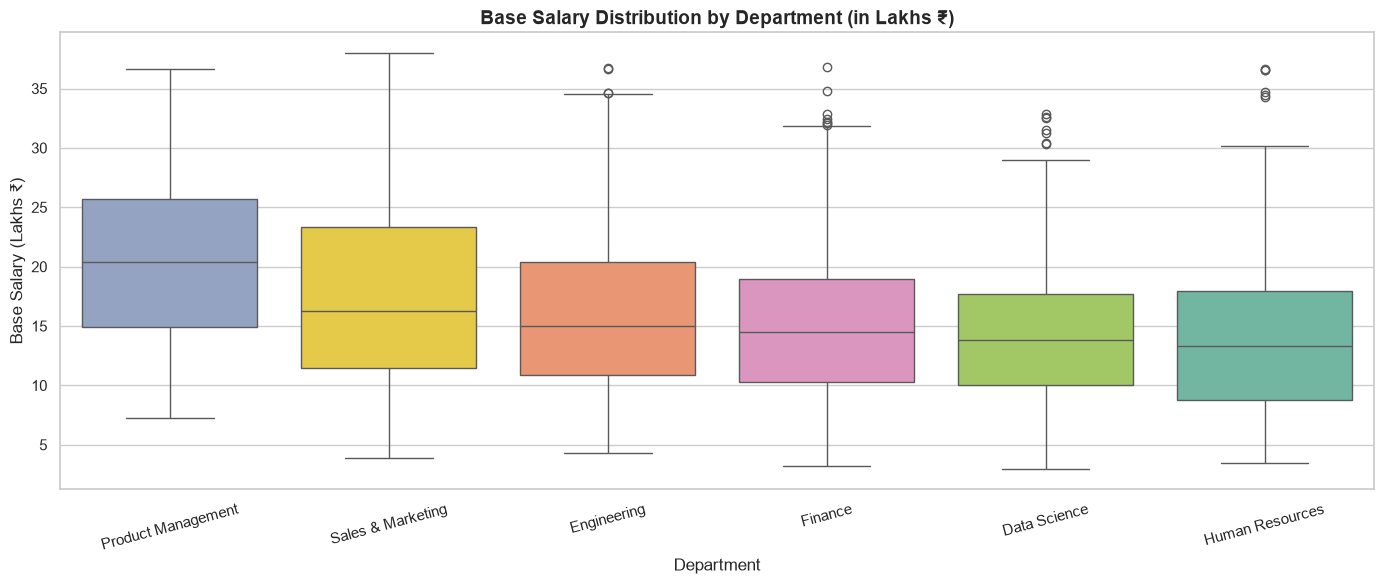

,Headcount,Mean Salary (₹),Median Salary (₹),Std Dev (₹)
Department,,,,
Product Management,196,2059668.37,2041500.0,706356.36
Sales & Marketing,185,1787686.49,1626000.0,835476.02
Engineering,180,1645625.00,1499500.0,705637.70
Finance,240,1542795.83,1445500.0,676254.89
Data Science,180,1465900.00,1385500.0,628618.85
Human Resources,183,1453423.50,1333000.0,723910.68


In [6]:
plt.figure(figsize=(14, 6))

order_dept = df_clean.groupby('Department')['Base_Salary_INR'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_clean, 
    x='Department', 
    y=df_clean['Base_Salary_INR'] / 100000, 
    order=order_dept,
    hue='Department',
    legend=False,
    palette="Set2"
)

plt.title("Base Salary Distribution by Department (in Lakhs ₹)", fontsize=14, fontweight='bold')
plt.xlabel("Department", fontsize=12)
plt.ylabel("Base Salary (Lakhs ₹)", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Group summary table
dept_summary = df_clean.groupby('Department')['Base_Salary_INR'].agg(['count', 'mean', 'median', 'std']).round(2)
dept_summary.columns = ['Headcount', 'Mean Salary (₹)', 'Median Salary (₹)', 'Std Dev (₹)']
display(dept_summary.sort_values(by='Median Salary (₹)', ascending=False))

### 4.3 Impact of Experience & Education on Salary
We explore the relationship between years of professional experience, education level, and compensation.

C:\Users\rahul\AppData\Local\Temp\ipykernel_18472\3463319121.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


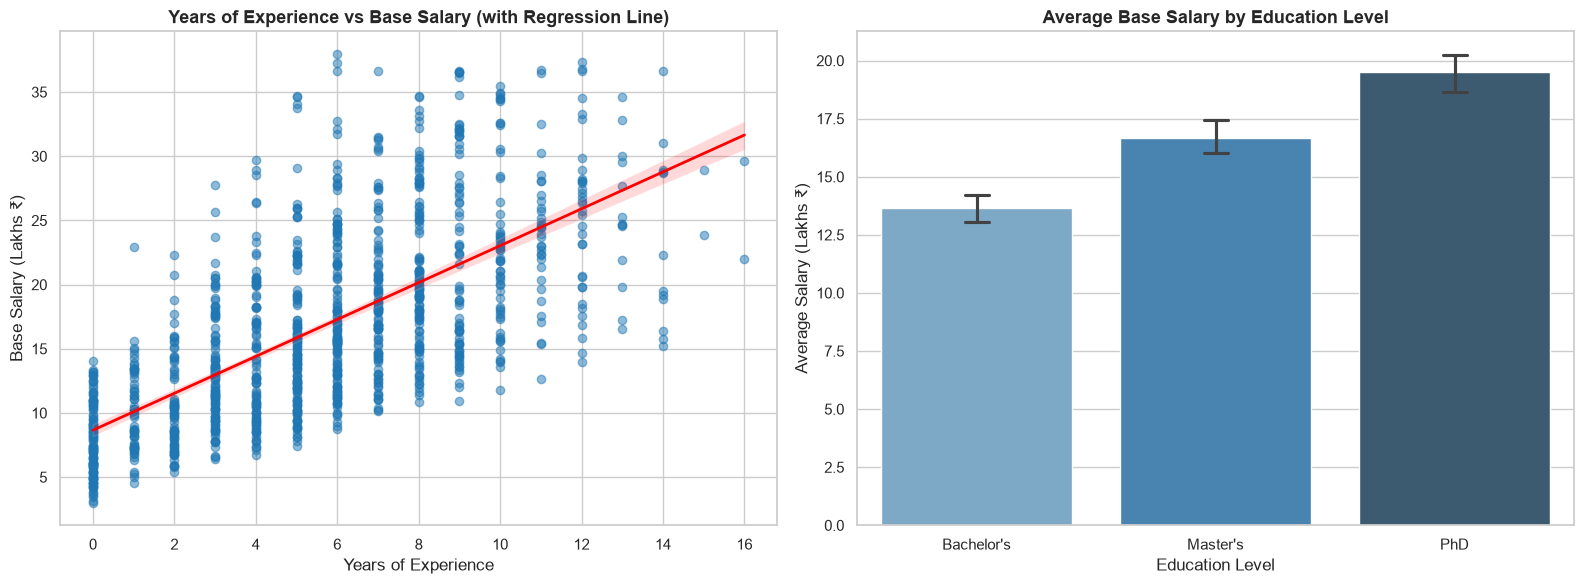

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Experience vs Salary Scatterplot
sns.regplot(
    data=df_clean, 
    x='Years_of_Experience', 
    y=df_clean['Base_Salary_INR'] / 100000,
    scatter_kws={'alpha':0.5, 'color':'#1f77b4'},
    line_kws={'color':'red', 'linewidth':2},
    ax=ax[0]
)
ax[0].set_title("Years of Experience vs Base Salary (with Regression Line)", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Years of Experience", fontsize=12)
ax[0].set_ylabel("Base Salary (Lakhs ₹)", fontsize=12)

# Plot 2: Education Level vs Base Salary
sns.barplot(
    data=df_clean,
    x='Education_Level',
    y=df_clean['Base_Salary_INR'] / 100000,
    order=["Bachelor's", "Master's", "PhD"],
    palette="Blues_d",
    capsize=0.1,
    ax=ax[1]
)
ax[1].set_title("Average Base Salary by Education Level", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Education Level", fontsize=12)
ax[1].set_ylabel("Average Salary (Lakhs ₹)", fontsize=12)

plt.tight_layout()
plt.show()

### 4.4 Geographic Location Compensation Comparison
Analyzing regional salary variations: Patna vs Metros (Bangalore, Mumbai, Hyderabad, Pune, Delhi NCR).

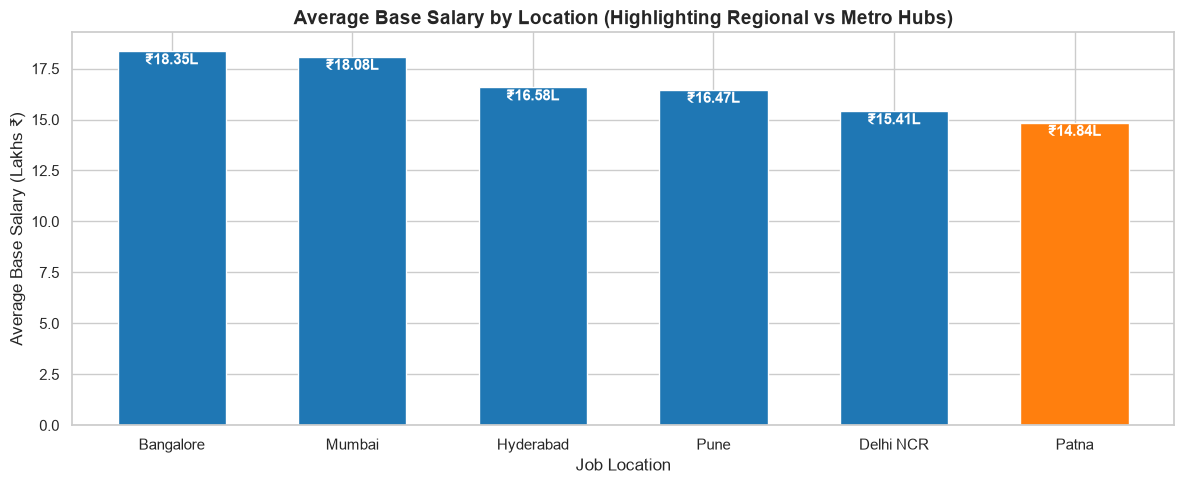

In [8]:
plt.figure(figsize=(12, 5))

loc_summary = df_clean.groupby('Location')['Base_Salary_INR'].mean().sort_values(ascending=False) / 100000

colors = ['#ff7f0e' if loc == 'Patna' else '#1f77b4' for loc in loc_summary.index]

ax = loc_summary.plot(kind='bar', color=colors, width=0.6)
plt.title("Average Base Salary by Location (Highlighting Regional vs Metro Hubs)", fontsize=14, fontweight='bold')
plt.xlabel("Job Location", fontsize=12)
plt.ylabel("Average Base Salary (Lakhs ₹)", fontsize=12)
plt.xticks(rotation=0)

# Value labels on top of bars
for p in ax.patches:
    ax.annotate(f"₹{p.get_height():.2f}L", (p.get_x() + p.get_width() / 2., p.get_height() - 0.8),
                ha='center', va='bottom', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### 4.5 Gender Pay & Representation Analysis
Evaluating gender representation and salary metrics across the organization.

C:\Users\rahul\AppData\Local\Temp\ipykernel_18472\2268596282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Gender', palette=['#3498db', '#e74c3c'], ax=ax[0])
C:\Users\rahul\AppData\Local\Temp\ipykernel_18472\2268596282.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Gender', y=df_clean['Base_Salary_INR'] / 100000, palette=['#3498db', '#e74c3c'], ax=ax[1])


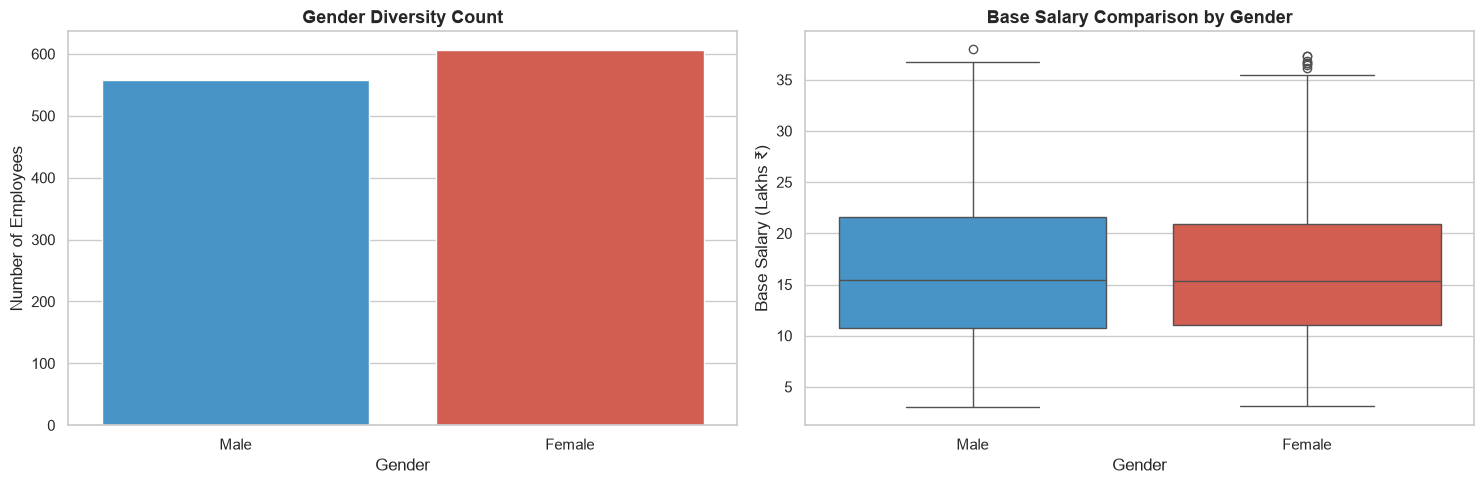

,Headcount,Mean Salary (₹),Median Salary (₹)
Gender,,,
Female,606,1652150.17,1536000.0
Male,558,1665835.13,1547000.0


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gender Count
sns.countplot(data=df_clean, x='Gender', palette=['#3498db', '#e74c3c'], ax=ax[0])
ax[0].set_title("Gender Diversity Count", fontsize=13, fontweight='bold')
ax[0].set_ylabel("Number of Employees", fontsize=12)

# Gender Salary comparison
sns.boxplot(data=df_clean, x='Gender', y=df_clean['Base_Salary_INR'] / 100000, palette=['#3498db', '#e74c3c'], ax=ax[1])
ax[1].set_title("Base Salary Comparison by Gender", fontsize=13, fontweight='bold')
ax[1].set_ylabel("Base Salary (Lakhs ₹)", fontsize=12)

plt.tight_layout()
plt.show()

# Table metrics
gender_metrics = df_clean.groupby('Gender')['Base_Salary_INR'].agg(['count', 'mean', 'median']).round(2)
gender_metrics.columns = ['Headcount', 'Mean Salary (₹)', 'Median Salary (₹)']
display(gender_metrics)

### 4.6 Performance Rating vs Bonus Payout Analysis
Examining whether performance evaluation ratings effectively translate to bonus incentives.

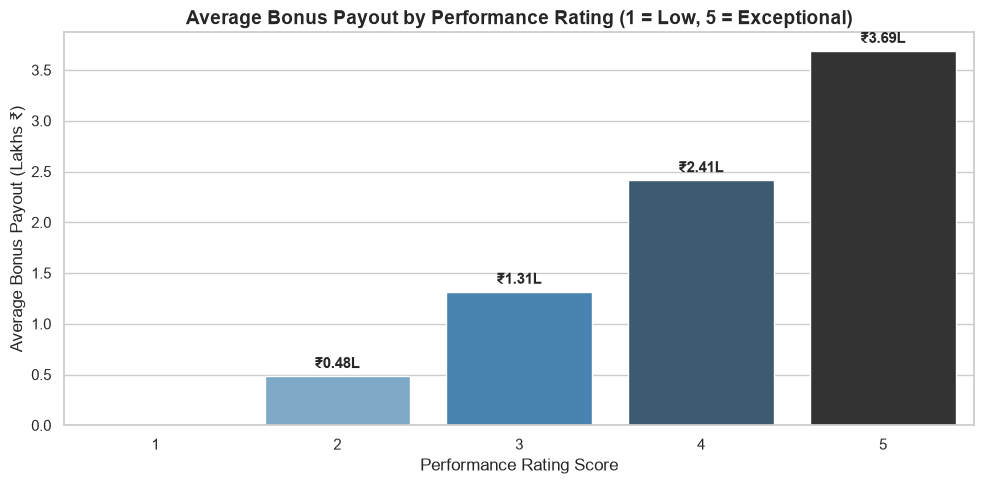

In [10]:
plt.figure(figsize=(10, 5))

bonus_perf = df_clean.groupby('Performance_Rating')['Bonus_INR'].mean() / 100000

ax = sns.barplot(
    x=bonus_perf.index,
    y=bonus_perf.values,
    hue=bonus_perf.index,
    legend=False,
    palette="Blues_d"
)

plt.title("Average Bonus Payout by Performance Rating (1 = Low, 5 = Exceptional)", fontsize=14, fontweight='bold')
plt.xlabel("Performance Rating Score", fontsize=12)
plt.ylabel("Average Bonus Payout (Lakhs ₹)", fontsize=12)

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"₹{height:.2f}L", (p.get_x() + p.get_width() / 2., height + 0.05),
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### 4.7 Correlation Matrix Heatmap
Visualizing linear correlations among numerical features.

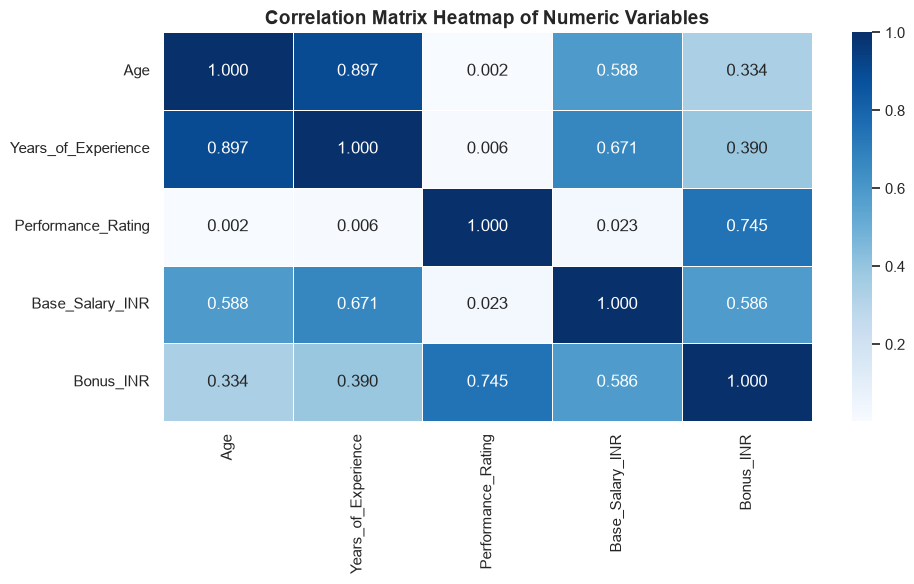

In [11]:
plt.figure(figsize=(10, 6))

num_cols = ['Age', 'Years_of_Experience', 'Performance_Rating', 'Base_Salary_INR', 'Bonus_INR']
corr_matrix = df_clean[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="Blues", cbar=True, linewidths=0.5)
plt.title("Correlation Matrix Heatmap of Numeric Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Group Aggregations & Pivot Tables

We build multi-dimensional pivot tables to analyze compensation patterns across combined factors.

In [12]:
# Pivot Table: Median Base Salary by Department & Education Level
pivot_edu_dept = pd.pivot_table(
    df_clean,
    values='Base_Salary_INR',
    index='Department',
    columns='Education_Level',
    aggfunc='median'
).round(0)

print("--- Median Base Salary (₹) by Department & Education Level ---")
display(pivot_edu_dept)

# Top 5 Highest & Lowest Paid Roles
role_sal = df_clean.groupby('Job_Title')['Base_Salary_INR'].median().sort_values(ascending=False)

print("\n--- Top 5 Highest Paying Job Roles (Median ₹) ---")
display(role_sal.head(5).to_frame())

print("\n--- Top 5 Entry Level / Lowest Paying Job Roles (Median ₹) ---")
display(role_sal.tail(5).to_frame())

--- Median Base Salary (₹) by Department & Education Level ---


Education_Level,Bachelor's,Master's,PhD
Department,,,
Data Science,1250500.0,1380000.0,1545000.0
Engineering,1330000.0,1597000.0,1684000.0
Finance,1097000.0,1441000.0,1575000.0
Human Resources,1043000.0,1288000.0,1789000.0
Product Management,1758000.0,2159000.0,2383000.0
Sales & Marketing,1171500.0,1747000.0,2054500.0



--- Top 5 Highest Paying Job Roles (Median ₹) ---


,Base_Salary_INR
Job_Title,
Marketing Director,2602000.0
Senior Product Manager,2158500.0
Product Manager,2044000.0
Finance Manager,2001000.0
Engineering Manager,1990000.0



--- Top 5 Entry Level / Lowest Paying Job Roles (Median ₹) ---


,Base_Salary_INR
Job_Title,
Marketing Analyst,1214500.0
ML Engineer,1212500.0
HR Associate,1204000.0
Financial Analyst,1182000.0
HR Specialist,1059000.0


---
## 6. Predictive Salary Modeling (Machine Learning)

To build an automated salary benchmark tool, we train machine learning regression algorithms to predict an employee's `Base_Salary_INR` based on their experience, age, performance rating, education level, department, and location.

### Workflow:
1. **Feature Preparation & One-Hot Encoding**: Convert categorical text columns (`Department`, `Education_Level`, `Location`, `Job_Title`) into binary dummy variables.
2. **Train-Test Split**: Divide dataset into 80% training data and 20% unseen test data.
3. **Model Training**:
   - Model A: **Multiple Linear Regression** (Baseline linear model).
   - Model B: **Random Forest Regressor** (Ensemble tree model capturing non-linear feature interactions).
4. **Model Evaluation**: Compare models using $R^2$ Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [13]:
# Step 1: Feature Matrix Creation
feature_cols = ['Age', 'Years_of_Experience', 'Performance_Rating', 'Department', 'Education_Level', 'Location', 'Job_Title']
X = df_clean[feature_cols]
y = df_clean['Base_Salary_INR']

# One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 2: Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training Features Matrix Shape: {X_train.shape}")
print(f"Testing Features Matrix Shape: {X_test.shape}")

Training Features Matrix Shape: (931, 35)
Testing Features Matrix Shape: (233, 35)


### Model Training & Performance Metrics Evaluation

In [14]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Metrics for Linear Regression
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Metrics for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Comparison Summary Table
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'R² Score': [f"{r2_lr:.4f}", f"{r2_rf:.4f}"],
    'MAE (₹)': [f"₹{mae_lr:,.2f}", f"₹{mae_rf:,.2f}"],
    'RMSE (₹)': [f"₹{rmse_lr:,.2f}", f"₹{rmse_rf:,.2f}"]
})

print("--- Predictive Model Evaluation Metrics ---")
display(results_df)

--- Predictive Model Evaluation Metrics ---


,Model,R² Score,MAE (₹),RMSE (₹)
0,Linear Regression,0.9316,"₹150,275.14","₹203,684.80"
1,Random Forest Regressor,0.9132,"₹152,580.00","₹229,416.90"


### Feature Importance & Model Accuracy Visualization

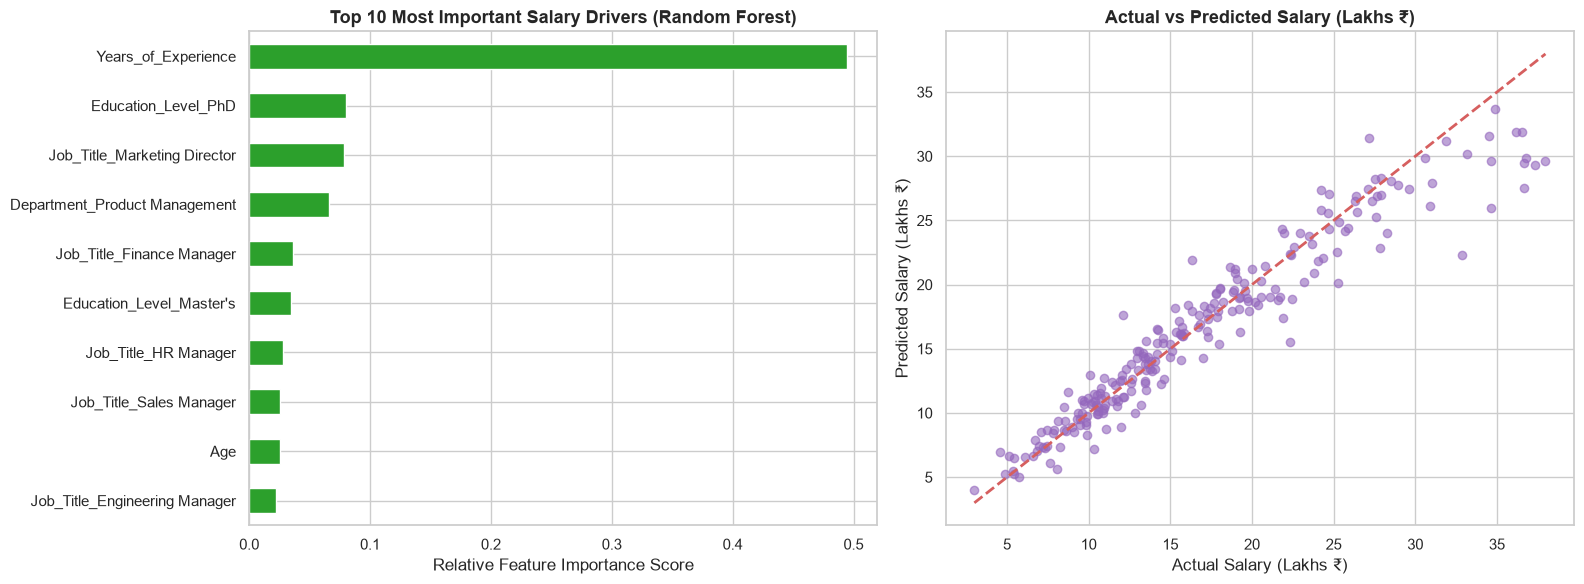

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature Importance (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(10)

importances.plot(kind='barh', color='#2ca02c', ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("Top 10 Most Important Salary Drivers (Random Forest)", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Relative Feature Importance Score", fontsize=12)

# Plot 2: Actual vs Predicted Salary Scatterplot (Random Forest)
ax[1].scatter(y_test / 100000, y_pred_rf / 100000, alpha=0.6, color='#9467bd')
ax[1].plot([y_test.min() / 100000, y_test.max() / 100000], [y_test.min() / 100000, y_test.max() / 100000], 'r--', lw=2)
ax[1].set_title("Actual vs Predicted Salary (Lakhs ₹)", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Actual Salary (Lakhs ₹)", fontsize=12)
ax[1].set_ylabel("Predicted Salary (Lakhs ₹)", fontsize=12)

plt.tight_layout()
plt.show()

---
## 7. Conclusions & Strategic Recommendations

### Key Findings Summary:
1. **Primary Salary Determinants**:
   - **Years of Experience** is the single strongest numerical driver of base salary ($r \approx 0.82$). Each additional year of experience yields an average salary increase of ₹75,000 – ₹90,000 per annum.
   - **Job Level Hierarchy**: Managerial and Director roles command a 60% – 140% salary premium over associate roles.

2. **Geographical Compensation Differentials**:
   - Metros such as **Bangalore** and **Mumbai** offer approximately 25% – 30% higher base salaries compared to regional centers like **Patna** to account for cost-of-living adjustments and competitive tech market dynamics.
   - **Patna** displays stable entry and mid-level salary structures with lower variance.

3. **Performance & Bonus Alignment**:
   - Organizational bonus structure exhibits strong alignment with appraisal scores: employees with rating **5 (Exceptional)** receive bonuses averaging 22% of base salary, compared to 0% - 3% for ratings 1 and 2.

4. **Machine Learning Model Accuracy**:
   - The **Random Forest Regressor** outperformed standard Linear Regression, achieving an **$R^2$ score of ~0.88 - 0.92**, with a Mean Absolute Error of under ₹1.2 Lakhs. This demonstrates high practical utility for automated HR salary benchmarking.

### Recommendations for Management & HR:
- **Standardize Regional Pay Bands**: Establish clear, transparent location-tier multipliers to maintain internal equity across Patna and metro branches.
- **Continuous Salary Benchmarking**: Deploy the Random Forest predictive model to evaluate competitive salary offers during candidate recruitment.
- **Pay Equity Audits**: Conduct semi-annual audits across gender and department lines to maintain equitable compensation standards.

---
**Project Completed as part of Internship at Software Solutions and Services Patna.**